# Exp_4 — Multivariate Analysis on the Wine Quality Dataset
**Date:** 18.08.2026

**Objective:** The Wine Quality dataset contains physicochemical measurements and quality scores.
This notebook performs multivariate analysis to explore relationships among the features and the
`quality` score, following the Univariate → Bivariate → Multivariate workflow from Module 3.

## Step 1: Import libraries and load the dataset

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats

sns.set(style="ticks", color_codes=True)
%matplotlib inline

df = pd.read_csv("WineQT.csv")
print("Shape:", df.shape)
df.head(3)

Shape: (1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2


In [2]:
df.tail(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


`WineQT.csv` has 1143 rows and 13 columns: 11 physicochemical measurements
(fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide,
total sulfur dioxide, density, pH, sulphates, alcohol), the target `quality` score, and an `Id`
column (a row identifier we will ignore in the analysis).

## Step 2: Check data types and missing values

In [3]:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

In [4]:
print(df.describe())
print()
print("Missing values per column:")
print(df.isna().sum())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
min       0.012000             1.000000         

All columns are already numeric (`int64`/`float64`) and there are **no missing values**,
so — unlike the automobiles dataset in Module 3 — no `'?'` cleaning or type conversion is needed here.
We can drop the `Id` column since it carries no analytical information.

In [5]:
df = df.drop(columns=["Id"])
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

## Step 3: Univariate Analysis
Univariate analysis looks at **one variable at a time** to summarize it and find patterns
(central tendency: mean, median, mode; dispersion: std, variance, range).
We'll start with `alcohol` and `quality`.

In [6]:
mean_alc = df["alcohol"].mean()
median_alc = df["alcohol"].median()
mode_alc = df["alcohol"].mode()[0]
std_alc = df["alcohol"].std()
var_alc = df["alcohol"].var()

print("Alcohol - Mean:", mean_alc)
print("Alcohol - Median:", median_alc)
print("Alcohol - Mode:", mode_alc)
print("Alcohol - Std Dev:", std_alc)
print("Alcohol - Variance:", var_alc)

Alcohol - Mean: 10.442111402741325
Alcohol - Median: 10.2
Alcohol - Mode: 9.5
Alcohol - Std Dev: 1.0821956098764445
Alcohol - Variance: 1.1711473380358497


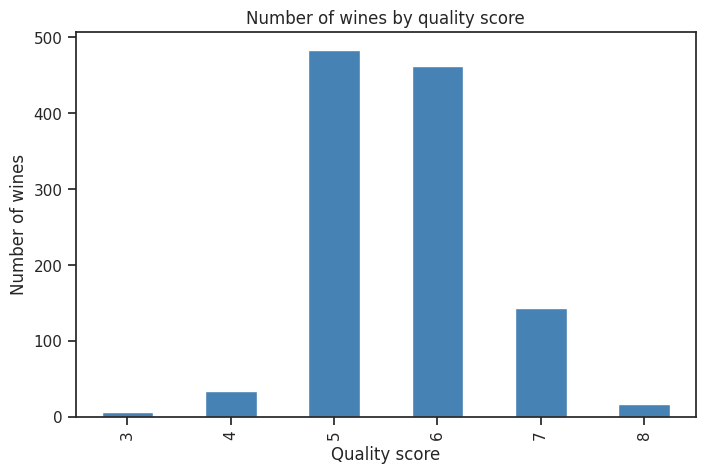

In [7]:
# Distribution of quality scores (bar chart, since quality is discrete)
df["quality"].value_counts().sort_index().plot(kind="bar", figsize=(8,5), color="steelblue")
plt.title("Number of wines by quality score")
plt.xlabel("Quality score")
plt.ylabel("Number of wines")
plt.show()

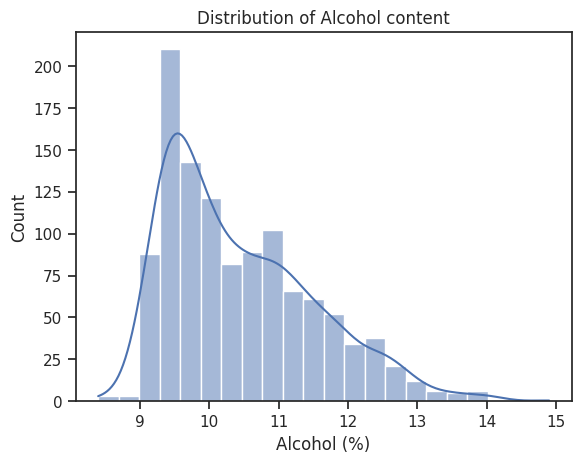

In [8]:
# Distribution plot for alcohol
sns.histplot(df["alcohol"], kde=True)
plt.title("Distribution of Alcohol content")
plt.xlabel("Alcohol (%)")
plt.show()

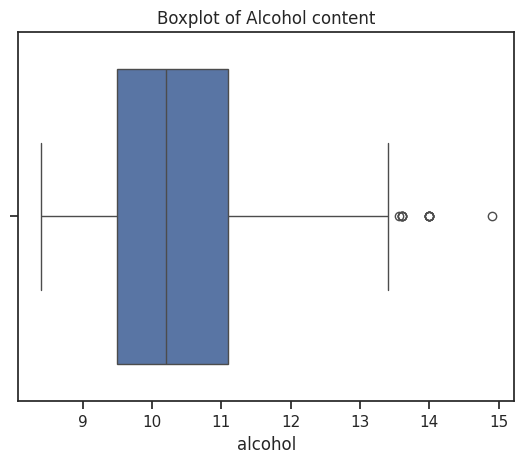

In [9]:
# Boxplot for alcohol to see spread and outliers
sns.boxplot(x="alcohol", data=df)
plt.title("Boxplot of Alcohol content")
plt.show()

Most wines cluster around quality scores 5 and 6. Alcohol content is right-skewed, roughly ranging from 8% to 15%, with a concentration around 9.5%.

## Step 4: Bivariate Analysis
Bivariate analysis examines the relationship **between exactly two variables** —
here, how each physicochemical property relates to wine `quality`.

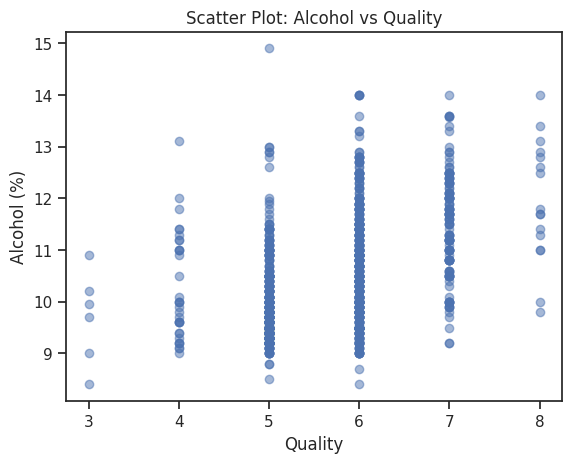

In [10]:
# Scatter plot: alcohol vs quality
plt.scatter(df["quality"], df["alcohol"], alpha=0.5)
plt.title("Scatter Plot: Alcohol vs Quality")
plt.xlabel("Quality")
plt.ylabel("Alcohol (%)")
plt.show()

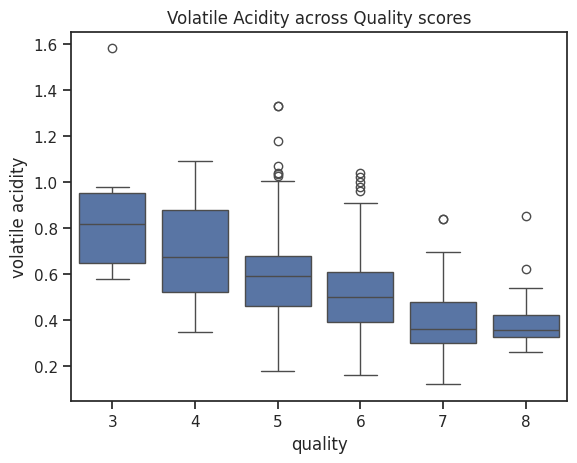

In [11]:
# Boxplot: volatile acidity across quality scores
sns.boxplot(x="quality", y="volatile acidity", data=df)
plt.title("Volatile Acidity across Quality scores")
plt.show()

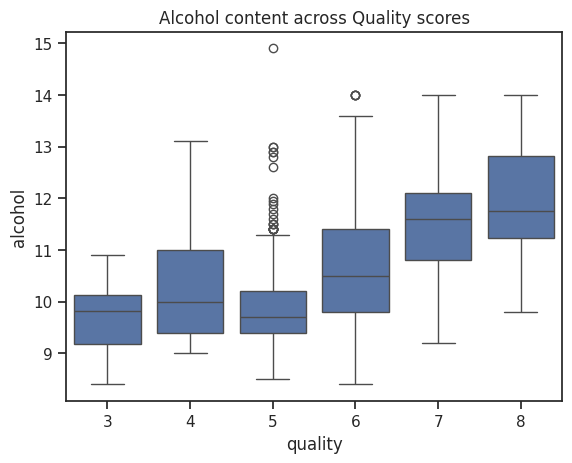

In [12]:
# Boxplot: alcohol across quality scores
sns.boxplot(x="quality", y="alcohol", data=df)
plt.title("Alcohol content across Quality scores")
plt.show()

Higher-quality wines tend to have **higher alcohol content** and **lower volatile acidity**
— volatile acidity gives wine a vinegar-like taste, so it makes sense that it trends down as
quality goes up.

## Step 5: Multivariate Analysis
Multivariate analysis looks at **three or more variables together** to find correlations and
patterns that bivariate analysis alone would miss.

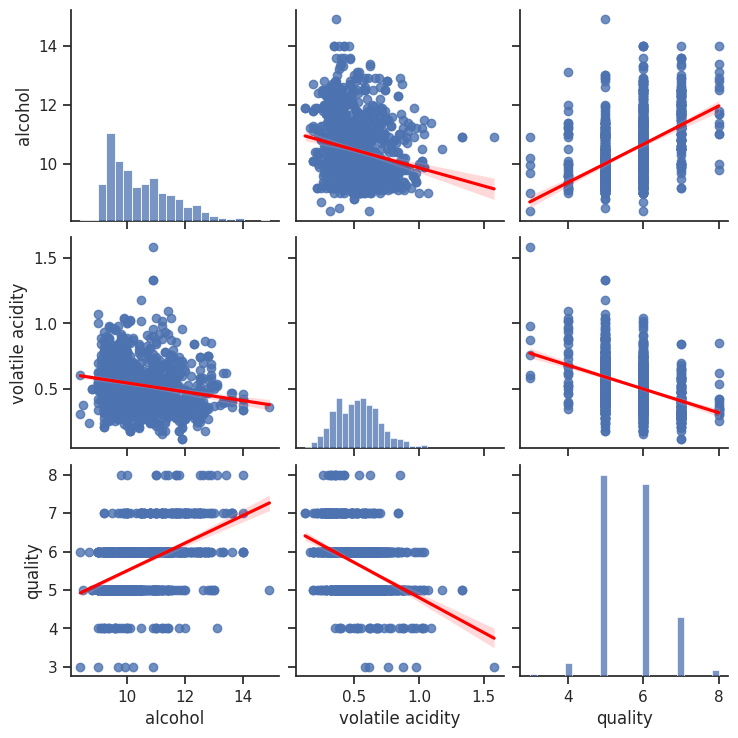

In [13]:
# Pair plot with regression lines for a few key features
sns.pairplot(df, vars=["alcohol", "volatile acidity", "quality"], kind="reg", plot_kws={'line_kws':{'color':'red'}})
plt.show()

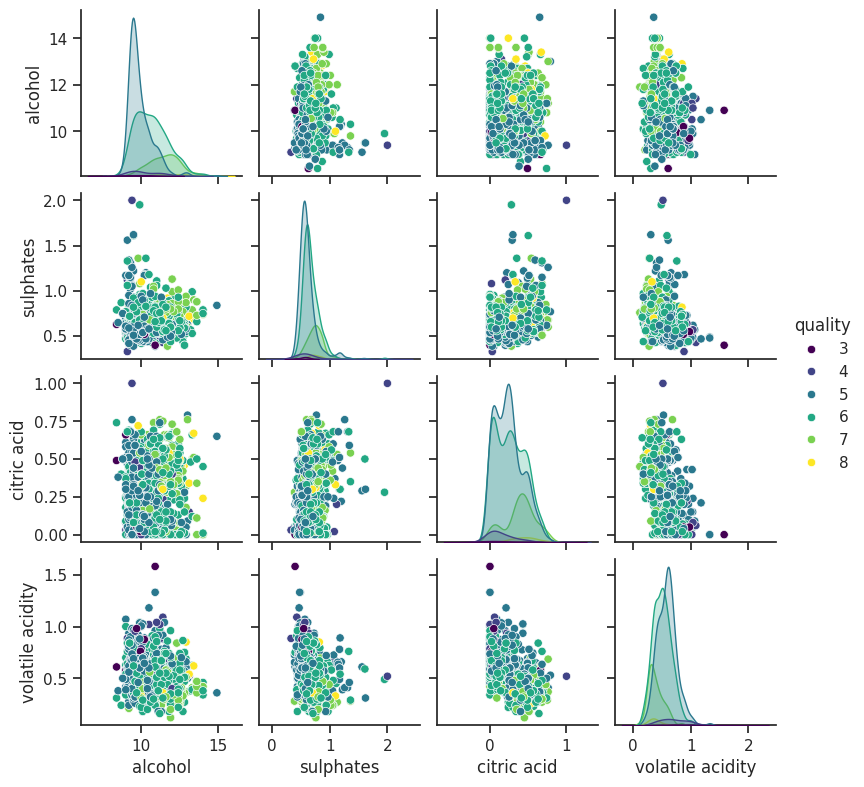

In [14]:
# Pair plot colored by quality for a broader set of features
sns.pairplot(df, vars=["alcohol", "sulphates", "citric acid", "volatile acidity"], hue="quality", height=2, palette="viridis")
plt.show()

In [15]:
# Pearson correlation coefficient between alcohol and quality
corr = stats.pearsonr(df["alcohol"], df["quality"])
print("Correlation (alcohol vs quality):", corr[0])
print("p-value:", corr[1])

Correlation (alcohol vs quality): 0.4848662118085117
p-value: 1.9246528151001656e-68


In [16]:
# Correlation matrix for all numeric columns
correlation = df.corr(method="pearson", numeric_only=True)
correlation

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.107889,-0.164831,-0.110628,0.681501,-0.685163,0.174592,-0.075055,0.121970
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056336,-0.001962,0.077748,0.016512,0.221492,-0.276079,-0.203909,-0.407394
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245312,-0.057589,0.036871,0.375243,-0.546339,0.331232,0.106250,0.240821
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070863,0.165339,0.190790,0.380147,-0.116959,0.017475,0.058421,0.022002
chlorides,0.107889,0.056336,0.245312,0.070863,1.000000,0.015280,0.048163,0.208901,-0.277759,0.374784,-0.229917,-0.124085
free sulfur dioxide,-0.164831,-0.001962,-0.057589,0.165339,0.015280,1.000000,0.661093,-0.054150,0.072804,0.034445,-0.047095,-0.063260
total sulfur dioxide,-0.110628,0.077748,0.036871,0.190790,0.048163,0.661093,1.000000,0.050175,-0.059126,0.026894,-0.188165,-0.183339
density,0.681501,0.016512,0.375243,0.380147,0.208901,-0.054150,0.050175,1.000000,-0.352775,0.143139,-0.494727,-0.175208
pH,-0.685163,0.221492,-0.546339,-0.116959,-0.277759,0.072804,-0.059126,-0.352775,1.000000,-0.185499,0.225322,-0.052453
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374784,0.034445,0.026894,0.143139,-0.185499,1.000000,0.094421,0.257710


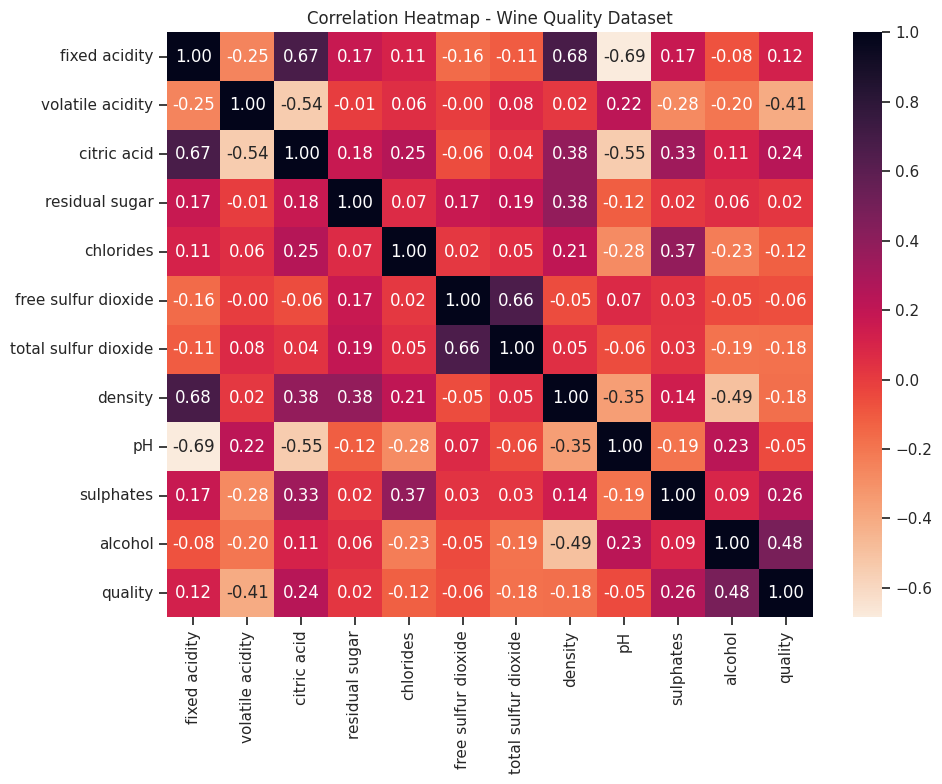

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation, xticklabels=correlation.columns, yticklabels=correlation.columns,
            cmap="rocket_r", annot=True, fmt=".2f")
plt.title("Correlation Heatmap - Wine Quality Dataset")
plt.tight_layout()
plt.show()

In [18]:
# Which features correlate most strongly with quality?
correlation["quality"].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64

## Conclusion

- **Alcohol** shows the strongest positive correlation with `quality` (~0.48), followed by
  `sulphates` and `citric acid` — wines with more alcohol, more sulphates, and more citric acid
  tend to score higher.
- **Volatile acidity** shows the strongest negative correlation with `quality` (~ -0.41) —
  higher volatile acidity is associated with lower quality wines.
- Features like `density`, `chlorides`, and `total sulfur dioxide` show weak correlation with
  quality, suggesting they are less influential (at least linearly) in determining perceived wine quality.
- The heatmap also reveals strong relationships *among the predictors themselves* — e.g.,
  `fixed acidity` correlates strongly with `citric acid` and `density`, which is useful context
  if this dataset were later used for regression modelling (multicollinearity).
